In [1]:
import os
import json
from PIL import Image
from scipy.ndimage import gaussian_filter

import cv2
import numpy as np
import torch

from vision_process import process_vision_info
from orthography import Orthophoto
from dataset.vis_data import visualize_waypoints
from pathlib import Path

video_frame_num = 5
target_interval = 30
data_list_json_paths = ["../data/train_data_sample.json"]
visualize = False
sigma = 20
visual_prompt = True

data_list = []
for file in data_list_json_paths:
    with open(file, "r") as f:
        datum = json.load(f)
    data_list += datum

data = data_list

ortho_processor = Orthophoto(granularity=0.3)

idx = 2200

def preprocess(image, pad_color=(0, 0, 0)):
    img_size = 784
    h, w = image.shape[:2]
    scale = img_size * 1.0 / max(h, w)
    new_h, new_w = h * scale, w * scale
    new_w = int(new_w + 0.5)
    new_h = int(new_h + 0.5)
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    resized_hw = (new_h, new_w)

    pad_h = img_size - new_h
    pad_w = img_size - new_w
    padded_image = cv2.copyMakeBorder(resized_image, 0, pad_h, 0, pad_w,
                                    cv2.BORDER_CONSTANT, value=pad_color)
    return padded_image, resized_hw

def generate_prob_message_v2(pil_image, description):
    visual_prompt = True
    if isinstance(pil_image, np.ndarray):
        pil_image = Image.fromarray(pil_image)
    if isinstance(description, list):
        description = description[0]
    text_parts = description.split("The description of the target and its surrounding is shown below.")
    direction = text_parts[0].strip().split("Compass north corresponds to the top of the bird's-eye-view image.")[-1]
    direction = direction.strip()
    object_description = text_parts[-1].strip()

    prob_message = [{
        'role':'user',
        'content':[
            {'type':'image', 'image':pil_image},
            {'type':'text', 'text': "Task: Predict the probability distribution of the drone's future flight locations to search for the target."
            "Input Image: The image is an orthophoto map generated from the drone's past flight trajectory."},
            {'type':'text', 'text': "The green dots indicate past drone positions." if visual_prompt else " "},
            {'type':'text', 'text': "The top of the image corresponds to the north in the world coordinate system.\n" 
            f"Target Information: {direction}"
            f"The description of the target and its surrounding is shown below: {object_description}\n"
            "Objective: "
            "Analyze the provided orthophoto map and target information."
            "Predict the next flight location for the drone that maximize the probability of finding the target."
            "Output a probability map, indicating the likelihood of different regions in the orthophoto map being the optimal next flight destinations."
            }
        ]
    },
    {
        'role':'assistant',
        'content':[
            {'type':'image', 'image':pil_image}
        ]
    }
    ]
    return prob_message
    
def gaussian(target, img_size):
    sigma = 20
    h, w = img_size
    prob_map = np.zeros((h, w), dtype=np.float32)
    i, j = target
    i, j = min(round(i),h-1), min(round(j),w-1)
    i_1 = min(h-1, i+1)
    j_1 = min(w-1, j+1)
    i_2 = max(0, i-1)
    j_2 = max(0, j-1)
    prob_map[i, j] = 1
    prob_map[i, j_1] = 1
    prob_map[i, j_2] = 1
    prob_map[i_1, j] = 1
    prob_map[i_2, j] = 1

    sigma = max(h,w) // 25 if sigma is None else sigma
    prob_map = gaussian_filter(prob_map, sigma=sigma)
    return prob_map

def get_prob_map(ortho, coor_map, end, ortho_depth=None, delta_height=None):
    h, w = ortho.shape[:2]
    if ortho_depth is not None:
        depth_mask = (ortho_depth > delta_height).reshape(h,w)
    i, j = ortho_processor.world_to_pixel(end, coor_map=coor_map)
    i, j = min(max(round(i), 0), h-1), min(max(round(j), 0), w-1)
    prob_map_0 = np.zeros((h, w))
    prob_map_0[i, j] = 1

    yy, xx = np.ogrid[:h, :w]
    distances = np.sqrt((yy - i)**2 + (xx - j)**2)
    max_dist = np.sqrt(2*(h-1)**2)
    prob_map_0 = 1 - distances / max_dist
    prob_map_0[~depth_mask] = 0

    new_i, new_j = np.unravel_index(np.argmax(prob_map_0), (h, w))
    prob_map = gaussian((new_i, new_j), (h, w))
    # prob_map[~depth_mask] = 0
    prob_map = prob_map / (np.max(prob_map) + 1e-6)

    return prob_map, depth_mask


data_info = data[idx]
traj_dir = data_info["traj_folder_path"]
traj_dir = os.path.join("..", traj_dir)
depth_dir = os.path.join(traj_dir, "bevcamera_depth")
image_dir = os.path.join(traj_dir, "bevcamera")
log_dir = os.path.join(traj_dir, "log")
image_path = data_info["image_path"]

high_uav_pos_now = data_info["high_uav_pos_now"]
end_pos = data_info["end_pos"]
int_time = data_info["int_time"]
target_time = int_time+target_interval

description_path = os.path.join(traj_dir, "object_description_with_help.json")
with open(description_path, 'r') as f:
    description = json.load(f)
description = description[0]

image_files = sorted([f for f in os.listdir(image_dir)])
image_numbers = sorted([int(f.split('.')[0]) for f in image_files])
available_images = [t for t in image_numbers if t <= int_time]
available_num = len(available_images)
if available_num > video_frame_num:
    indices = [round(i * (available_num - 1) / (video_frame_num - 1)) for i in range(video_frame_num)]
    available_images = [available_images[i] for i in indices]
names = [f"{t:06d}" for t in available_images]

# historial orthography
frame_paths = [os.path.join(image_dir, f"{idx}.png") for idx in names]
log_paths = [os.path.join(log_dir, f"{idx}.json") for idx in names]
depth_paths = [os.path.join(depth_dir, f"{idx}.png") for idx in names]
positions = np.array([
            json.load(open(log_path, "r"))["sensors"]["state"]["position"] for log_path in log_paths
            ])
frames = np.array([cv2.imread(frame_path) for frame_path in frame_paths])
depths = np.array([cv2.imread(depth_path, cv2.IMREAD_UNCHANGED) for depth_path in depth_paths])

In [2]:
description

"Compass north corresponds to the top of the bird's-eye-view image. The target location is 55.89 degrees south by east from the starting point. The description of the target and its surrounding is shown below.The woman is sitting in an open area with a concrete surface surrounded by benches, street lamps, and palm trees near a beach, and is located near urban buildings, including high-rise structures and smaller commercial buildings, with a street visible in the vicinity."

In [3]:
frames.shape

(5, 1024, 1024, 3)

In [4]:
frame_paths

['../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000000.png',
 '../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000010.png',
 '../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000015.png',
 '../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000020.png',
 '../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000030.png']

In [52]:
image_path = Path(frame_paths[4])
image_path

PosixPath('../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000030.png')

In [53]:
from high_uav.noun_extractor import parse_instruction, build_prompt_list

goal, contextual, desc = parse_instruction(description_path)

In [54]:
from high_uav.bev_segmentation import *

In [55]:
device = 'cuda' if torch.cuda.is_available else 'cpu'

In [56]:
sam2_pred, gdino_model, dev = load_models(device)

In [57]:
goal_object = goal
contextual_nouns = contextual
sam2_predictor = sam2_pred
grounding_model=gdino_model


In [58]:
def _normalise_category(category: Optional[str]) -> Optional[str]:
    """Normalise prompt/category names for stable comparison and storage."""
    if category is None:
        return None
    cleaned = category.strip().lower().rstrip(".")
    return cleaned or None

image_source, image_tensor = load_image(str(image_path))
h, w = image_source.shape[:2]

goal_object = _normalise_category(goal_object)
contextual_nouns = [_normalise_category(noun) for noun in contextual_nouns]

prompt_list = build_prompt_list(goal_object, contextual_nouns)


box_threshold = BOX_THRESHOLD
text_threshold = TEXT_THRESHOLD
nms_iou = NMS_IOU_THRESH

In [59]:
from grounding_dino.groundingdino.util.inference import load_model, load_image, predict

def _detect_per_prompt(
    image_tensor: torch.Tensor,
    image_width: int,
    image_height: int,
    prompt_list: list[str],
    goal_object: Optional[str],
    grounding_model,
    device: str,
    box_threshold: float,
    text_threshold: float,
) -> list[dict]:
    """
    Run GroundingDINO once per prompt so categories stay tied to the extracted nouns.
    """
    candidates = []
    goal_norm = _normalise_category(goal_object)
    prompt_count = max(len(prompt_list), 1)

    for prompt_index, prompt in enumerate(prompt_list):
        prompt_norm = _normalise_category(prompt)
        if not prompt_norm:
            continue

        boxes_cx, confidences, labels = predict(
            model=grounding_model,
            image=image_tensor,
            caption=f"{prompt_norm}.",
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            device=device,
        )
        if len(boxes_cx) == 0:
            continue

        boxes_px = box_convert(
            boxes_cx * torch.tensor([image_width, image_height, image_width, image_height], dtype=torch.float32),
            in_fmt="cxcywh",
            out_fmt="xyxy",
        ).numpy()
        conf_np = confidences.numpy()

        is_goal_prompt = goal_norm is not None and prompt_norm == goal_norm
        priority_bonus = 1.0 if is_goal_prompt else 0.01 * (prompt_count - prompt_index)

        for bbox, confidence, raw_label in zip(boxes_px.tolist(), conf_np.tolist(), labels):
            candidates.append({
                "prompt_index": prompt_index,
                "prompt": prompt_norm,
                "category": prompt_norm,
                "raw_grounding_label": raw_label.strip(),
                "bbox_xyxy": bbox,
                "confidence": float(confidence),
                "nms_score": float(confidence) + priority_bonus,
                "is_goal": is_goal_prompt,
            })

    return candidates

candidates = _detect_per_prompt(
        image_tensor=image_tensor,
        image_width=w,
        image_height=h,
        prompt_list=prompt_list,
        goal_object=goal_object,
        grounding_model=grounding_model,
        device=device,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
    )

In [60]:
candidates

[{'prompt_index': 1,
  'prompt': 'smaller commercial buildings',
  'category': 'smaller commercial buildings',
  'raw_grounding_label': 'smaller commercial buildings',
  'bbox_xyxy': [715.087158203125,
   0.809844970703125,
   1021.4979248046875,
   725.2662353515625],
  'confidence': 0.5889204144477844,
  'nms_score': 0.6589204144477845,
  'is_goal': False},
 {'prompt_index': 1,
  'prompt': 'smaller commercial buildings',
  'category': 'smaller commercial buildings',
  'raw_grounding_label': 'smaller commercial buildings',
  'bbox_xyxy': [697.1412963867188,
   804.4127197265625,
   1022.3638305664062,
   1022.232421875],
  'confidence': 0.5326479077339172,
  'nms_score': 0.6026479077339173,
  'is_goal': False},
 {'prompt_index': 1,
  'prompt': 'smaller commercial buildings',
  'category': 'smaller commercial buildings',
  'raw_grounding_label': 'smaller commercial buildings',
  'bbox_xyxy': [189.28057861328125,
   783.0340576171875,
   534.5375366210938,
   1022.2021484375],
  'confid

In [61]:
def _apply_nms(boxes_xyxy: np.ndarray, scores: np.ndarray, iou_thresh: float):
    """Return indices of detections surviving NMS."""
    if len(boxes_xyxy) == 0:
        return np.array([], dtype=int)
    t_boxes  = torch.from_numpy(boxes_xyxy.astype(np.float32))
    t_scores = torch.from_numpy(scores.astype(np.float32))
    keep = torchvision_nms(t_boxes, t_scores, iou_thresh)
    return keep.numpy()




boxes_px = np.asarray([cand["bbox_xyxy"] for cand in candidates], dtype=np.float32)
nms_scores = np.asarray([cand["nms_score"] for cand in candidates], dtype=np.float32)
keep = _apply_nms(boxes_px, nms_scores, nms_iou)
kept_candidates = [candidates[i] for i in keep.tolist()]

kept_candidates.sort(key=lambda c: (-int(c["is_goal"]), c["prompt_index"], -c["confidence"]))
boxes_px = np.asarray([cand["bbox_xyxy"] for cand in kept_candidates], dtype=np.float32)

In [62]:
sam2_predictor.set_image(image_source)

In [63]:
image_source.shape

(1024, 1024, 3)

In [64]:
masks, scores, _ = sam2_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=boxes_px,
            multimask_output=False,
        )

if masks.ndim == 4:
    masks = masks[:, 0]  # (N, H, W)

In [65]:
goal_detected = False
detections = []

for idx, (candidate, bbox, mask) in enumerate(zip(kept_candidates, boxes_px.tolist(), masks)):
    is_goal = bool(goal_object and candidate["category"] == goal_object)
    if is_goal:
        goal_detected = True

    detections.append({
        "id":               idx,
        "category":         candidate["category"],
        "bbox_xyxy":        [round(v, 2) for v in bbox],
        "confidence":       round(float(candidate["confidence"]), 4),
        "is_goal":          is_goal,
        "source_prompt":    candidate["prompt"],
        "prompt_index":     candidate["prompt_index"],
        "grounding_phrase": candidate["raw_grounding_label"],
        "mask_key":         f"mask_{idx:04d}",
        "dinov2_embedding": None,   # filled by Stage 1a
    })

result = {
    "image_path":    str(image_path),
    "image_width":   w,
    "image_height":  h,
    "goal_category": goal_object,
    "goal_detected": goal_detected,
    "prompt_list":   prompt_list,
    "num_detections": len(detections),
    "detections":    detections,
    "masks_npz_path": None,   # filled after saving
}
# Attach raw masks for saving (not serialised to JSON)
result["_masks_array"] = masks


In [66]:
result

{'image_path': '../data/Hal-13k/Carla_Town10HD/49e98d3d-4f54-4c86-9b1a-eaefe1349611/bevcamera/000030.png',
 'image_width': 1024,
 'image_height': 1024,
 'goal_category': 'woman',
 'goal_detected': False,
 'prompt_list': ['woman',
  'smaller commercial buildings',
  'high-rise structures',
  'concrete surface',
  'urban buildings',
  'street lamps',
  'palm trees',
  'benches'],
 'num_detections': 10,
 'detections': [{'id': 0,
   'category': 'smaller commercial buildings',
   'bbox_xyxy': [697.14, 804.41, 1022.36, 1022.23],
   'confidence': 0.5326,
   'is_goal': False,
   'source_prompt': 'smaller commercial buildings',
   'prompt_index': 1,
   'grounding_phrase': 'smaller commercial buildings',
   'mask_key': 'mask_0000',
   'dinov2_embedding': None},
  {'id': 1,
   'category': 'smaller commercial buildings',
   'bbox_xyxy': [189.28, 783.03, 534.54, 1022.2],
   'confidence': 0.4275,
   'is_goal': False,
   'source_prompt': 'smaller commercial buildings',
   'prompt_index': 1,
   'groun

In [67]:
_COLOURS = [
    (0,   255, 50),    # goal: bright green
    (255, 100,  20),   # contextual colours below
    (0,   180, 255),
    (200,  60, 255),
    (255, 220,   0),
    (0,   255, 200),
    (255,  80, 160),
    (80,  180, 255),
    (255, 160,  80),
    (60,  255, 120),
    (200, 120, 255),
    (255, 255,  80),
]

In [68]:
def visualise_segmentation(result: dict, masks: dict[str, np.ndarray]) -> np.ndarray:
    """
    Overlay masks, bounding boxes, and labels on the original BEV image.

    Goal object: brighter colour + thicker box border.
    Returns an annotated BGR image (numpy array).
    """
    img = cv2.imread(result["image_path"])
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {result['image_path']}")
    overlay = img.copy()

    # Sort: draw contextual first, goal on top
    detections = sorted(result["detections"], key=lambda d: d["is_goal"])

    colour_idx = 1   # 0 is reserved for goal
    for det in detections:
        mask_arr = masks.get(det["mask_key"])
        if mask_arr is None:
            continue

        if det["is_goal"]:
            colour = _COLOURS[0]
            border_thickness = 3
            alpha = 0.55
        else:
            colour = _COLOURS[colour_idx % len(_COLOURS)]
            colour_idx += 1
            border_thickness = 2
            alpha = 0.40

        # Colour mask
        mask_bool = mask_arr.astype(bool)
        coloured   = np.zeros_like(overlay)
        coloured[mask_bool] = colour
        overlay    = cv2.addWeighted(overlay, 1.0, coloured, alpha, 0)

        # Bounding box
        x1, y1, x2, y2 = [int(v) for v in det["bbox_xyxy"]]
        cv2.rectangle(overlay, (x1, y1), (x2, y2), colour, border_thickness)

        # Label
        label = f"{'[GOAL] ' if det['is_goal'] else ''}{det['category']} {det['confidence']:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        ty = max(y1 - 5, th + 4)
        cv2.rectangle(overlay, (x1, ty - th - 4), (x1 + tw + 4, ty + 2), colour, -1)
        cv2.putText(overlay, label, (x1 + 2, ty), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 0, 0), 1, cv2.LINE_AA)

    return overlay

In [69]:
result["instruction_path"] = str(description_path)
result["description_text"] = desc
result["contextual_categories"] = contextual

# Save masks + JSON
masks_raw = result.get("_masks_array", np.zeros((0,), dtype=bool))
masks_dict = {d["mask_key"]: masks_raw[i] for i, d in enumerate(result["detections"])}

In [70]:
vis_img = visualise_segmentation(result, masks_dict)

In [71]:
vis_img

array([[[192, 208, 217],
        [191, 207, 217],
        [191, 207, 217],
        ...,
        [200,  60, 255],
        [200,  60, 255],
        [200,  60, 255]],

       [[191, 207, 217],
        [192, 208, 217],
        [193, 208, 218],
        ...,
        [200,  60, 255],
        [200,  60, 255],
        [200,  60, 255]],

       [[191, 207, 217],
        [192, 208, 218],
        [194, 209, 218],
        ...,
        [200,  60, 255],
        [200,  60, 255],
        [200,  60, 255]],

       ...,

       [[151, 151, 161],
        [148, 148, 155],
        [145, 143, 150],
        ...,
        [255, 100,  20],
        [255, 100,  20],
        [255, 100,  20]],

       [[155, 155, 164],
        [158, 157, 165],
        [150, 152, 158],
        ...,
        [255, 100,  20],
        [255, 100,  20],
        [255, 100,  20]],

       [[148, 147, 153],
        [160, 162, 168],
        [150, 150, 160],
        ...,
        [255, 100,  20],
        [255, 100,  20],
        [126, 124, 126]]

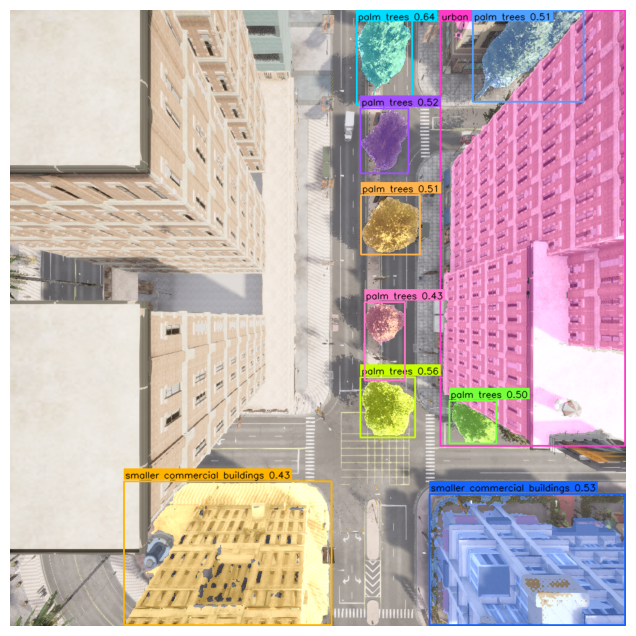

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

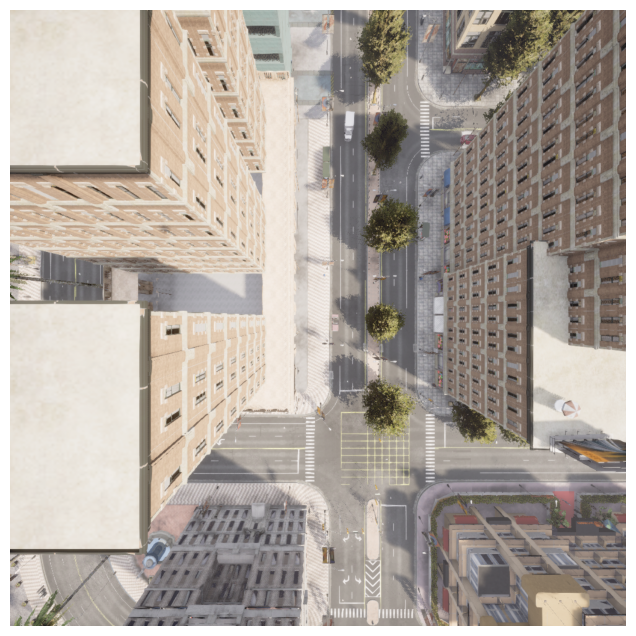

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(frames[4], cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [51]:
description

"Compass north corresponds to the top of the bird's-eye-view image. The target location is 55.89 degrees south by east from the starting point. The description of the target and its surrounding is shown below.The woman is sitting in an open area with a concrete surface surrounded by benches, street lamps, and palm trees near a beach, and is located near urban buildings, including high-rise structures and smaller commercial buildings, with a street visible in the vicinity."